In [ ]:
from typing import Literal , TypedDict
from langgraph.graph import StateGraph , START, END
from langchain_ollama import ChatOllama
from pydantic import Field, BaseModel
model = "qwen3.5:9b"
 

llm = ChatOllama(
    model=model,
    temperature=0
)

# response = llm.invoke("Explain Newton's second law simply.")

# print(response.content)

In [68]:
from typing import TypedDict

from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama


# --------------------------------------------------
# 1. Define the state
# --------------------------------------------------

class BlogState(TypedDict):
    topic: str
    outline: str
    blog: str


# --------------------------------------------------
# 2. Connect to your local Ollama model
# --------------------------------------------------

llm = ChatOllama(
    model=model,
    temperature=0.3
)


# --------------------------------------------------
# 3. Node: Create outline
# --------------------------------------------------

def create_outline(state: BlogState):

    prompt = f"""
    Create a clear blog outline about the following topic:

    Topic: {state["topic"]}

    Include:
    - Introduction
    - Main sections
    - Important subtopics
    - Conclusion
    """

    response = llm.invoke(prompt)

    return {
        "outline": response.content
    }


# --------------------------------------------------
# 4. Node: Create blog
# --------------------------------------------------

def create_blog(state: BlogState):

    prompt = f"""
    Write a professional and informative blog about:

    Topic:
    {state["topic"]}

    Use the following outline:

    {state["outline"]}

    Write the complete blog with clear headings,
    explanations, and a conclusion.
    """

    response = llm.invoke(prompt)

    return {
        "blog": response.content
    }


# --------------------------------------------------
# 5. Create the graph
# --------------------------------------------------

graph = StateGraph(BlogState)


# Add nodes
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)


# Add edges
graph.add_edge(START, "create_outline")

graph.add_edge(
    "create_outline",
    "create_blog"
)

graph.add_edge(
    "create_blog",
    END
)


# --------------------------------------------------
# 6. Compile the graph
# --------------------------------------------------

workflow = graph.compile()




In [69]:
# --------------------------------------------------
# 7. User gives a topic
# --------------------------------------------------

# topic = input("Enter blog topic: ")
topic = "what do you know about renhold number"


# --------------------------------------------------
# 8. Run the graph
# --------------------------------------------------

result = workflow.invoke({
    "topic": topic
})


# --------------------------------------------------
# 9. Display result
# --------------------------------------------------

print("\n--- OUTLINE ---\n")
print(result["outline"])

print("\n--- BLOG ---\n")
print(result["blog"])

KeyboardInterrupt: 

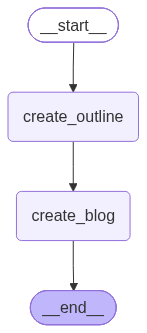

In [ ]:
from IPython.display import Image, display

display(
    Image(
        workflow.get_graph().draw_mermaid_png()
    )
)

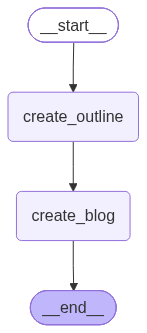

In [ ]:
Image(workflow.get_graph().draw_mermaid_png())

# LLM Based conditional workflows

In [88]:
from typing import Literal , TypedDict
from langgraph.graph import StateGraph , START, END
from langchain_ollama import ChatOllama
from pydantic import Field, BaseModel

llm = ChatOllama(
    model=model,
    temperature=0.0
)
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive","negative"]
    diagnosis: dict
    response: str
    
    

### Pydentic

In [89]:
class sentimentSchema(BaseModel):
    sentiment: Literal['positive','negative'] = Field(description='sentiment of the review')
class diagnosticSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"]
    tone: Literal["angry", "frustrated", "disappointed", "calm"]
    urgency: Literal["low", "medium", "high"]

### Define Functions


In [90]:
def find_sentiment(state:ReviewState)->ReviewState:
    llm_structure = llm.with_structured_output(sentimentSchema)
    result = llm_structure.invoke(state['review'])
    print(result.sentiment)
    return {'sentiment':result.sentiment}

def check_sentiment(state:ReviewState)->ReviewState:
    
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'    
    
def positive_response(state:ReviewState)->ReviewState:
    
     response = f"❤️❤️❤️Thank you for your {state['sentiment']} feedback" 
     return {
             "response":response
             }
def run_diagnosis(state:ReviewState)->ReviewState:
    
     llm_diagnostic = llm.with_structured_output(diagnosticSchema)
     prompt = f"what is the sentiment of following review {state['review']} which has {state['sentiment']} feedback"
     result_diagnostic = llm_diagnostic.invoke(prompt)
     print(result_diagnostic)
     

    
     response = f" 😒😒😒 we promise you to check your {state['sentiment']} feedback " 
 
     return {
             "response":response,
             "diagnosis":{
                     "issue_type": result_diagnostic.issue_type,
                     "tone": result_diagnostic.tone ,
                     "urgency": result_diagnostic.urgency
                  
             }}
  
  
  

### Create Nodes

In [91]:
graph = StateGraph(ReviewState)
graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagnosis',run_diagnosis)

In [92]:
graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis',END)
workflow = graph.compile()
 

In [93]:
init_state = {
    'review': "I really hate  this product.  fuck."
}
workflow.invoke(init_state)

negative
issue_type='Support' tone='frustrated' urgency='low'


{'review': 'I really hate  this product.  fuck.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Support',
  'tone': 'frustrated',
  'urgency': 'low'},
 'response': ' 😒😒😒 we promise you to check your negative feedback '}